# Week 5 lab — Dimensionality reduction: PCA and MDS on neural data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qihongl/NS5007/main/week5_pca_mds.ipynb)

Neural recordings are high-dimensional: hundreds of voxels or thousands of neurons, each one a dimension. The interesting structure — *what* the brain represents — usually lives in far fewer dimensions than that. Today we build two of the classic tools for exposing it:

- **PCA** (Principal Component Analysis) rotates the data onto its own main axes of variance.
- **MDS** (Multi-Dimensional Scaling) starts from pairwise distances alone and places every item on a 2D map that respects those distances.

We start with toy data you can picture in your head, then apply both methods to two real datasets:

1. **IT cortex responses to 92 everyday images**, human fMRI + monkey single-cell ([Kriegeskorte et al., 2008](https://doi.org/10.1016/j.neuron.2008.10.043)) — the dataset that launched representational similarity analysis (RSA).
2. **Hippocampal fMRI during sequences with temporal community structure** ([Schapiro et al., 2013](https://doi.org/10.1038/nn.3331)) — data from [OpenNeuro ds001621](https://openneuro.org/datasets/ds001621), preprocessed offline (despiking, motion correction, normalization) and packaged per region; `make_week5_derived_data.py` documents every step. Note the twist: the 2013 searchlight results are cortical, and we will test the hippocampal intuition as a control.

**Learning goals.** After this lab you can (i) run PCA and read scree plots and projections, (ii) build an RDM and embed it with MDS, (iii) say when one method beats the other, and (iv) go from raw BIDS fMRI to an embedding of stimulus codes.

About 5 minutes end-to-end on Colab — the fMRI preprocessing was done offline and the packaged pattern data (~15 MB, `data/`) loads instantly. All exercises have solutions hidden at the bottom.

> **Colab:** open with the badge above (notebook + data live in the course GitHub repo), or upload the notebook and the `data/` folder manually. The §5 bootstrap cell fetches the packaged fMRI patterns automatically.

In [1]:
import urllib.request
import os, sys, time

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        print(f'installing {pkg} ...')
        os.system(f'{sys.executable} -m pip install -q {pkg}')

ensure('nilearn')

# --- ANTsPy (only used in §5): import it, installing by canonical name if needed.
# The bare PyPI package `ants` is unrelated and breaks silently, so we verify the
# real API (registration + a nibabel bridge) rather than trusting any import.
import importlib

def _load_ants():
    """Return a working ANTsPy module; install/repair on demand."""
    def ok(m):
        conv = any(callable(getattr(m, n, None))
                   for n in ('from_nibabel', 'from_nibabel_nifti'))
        try:                       # newer builds keep converters in a submodule
            from ants.nibabel_nifti_to_ants import from_nibabel_nifti  # noqa
            conv = True
        except Exception:
            pass
        return all(hasattr(m, a) for a in ('registration', 'apply_transforms')) and conv

    try:
        mod = importlib.import_module('ants')
        if ok(mod):
            return mod
        print("found a non-functional `ants` package - replacing it ...")
    except ImportError:
        print('installing ANTsPy ...')
    os.system(f'{sys.executable} -m pip uninstall -q -y ants antspyx antspy')
    os.system(f'{sys.executable} -m pip install -q antspyx')
    importlib.invalidate_caches()
    for k in [k for k in list(sys.modules) if k == 'ants' or k.startswith('ants.')]:
        del sys.modules[k]
    mod = importlib.import_module('ants')
    if not ok(mod):
        raise RuntimeError('ANTsPy setup failed - restart the runtime and rerun '
                           '(fMRI results are cached, so this only bites once).')
    return mod

ants = _load_ants()

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.spatial.distance import squareform, pdist
from scipy.stats import spearmanr, zscore
import matplotlib.pyplot as plt
import matplotlib as mpl
import nibabel as nib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

np.random.seed(42)
mpl.rcParams['figure.dpi'] = 110

DATA_DIR = 'week5_data'
os.makedirs(DATA_DIR, exist_ok=True)

def fetch(url, dest):
    """Download url -> dest, skip if already there."""
    if os.path.exists(dest):
        print(f'cached: {dest}')
        return dest
    t0 = time.time()
    with urllib.request.urlopen(url) as r, open(dest, 'wb') as f:
        while True:
            chunk = r.read(1 << 22)
            if not chunk:
                break
            f.write(chunk)
    print(f'downloaded {dest} ({os.path.getsize(dest)/1e6:.1f} MB, {time.time()-t0:.0f}s)')
    return dest

rng = np.random.default_rng(42)
COMMUNITY_COLOR = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}

def plot_embedding(xy, labels, title='', ax=None):
    """Scatter an embedding colored by community letter; boundary nodes get black rings."""
    ax = ax or plt.gca()
    for lab, (x, y) in zip(labels, xy):
        c = COMMUNITY_COLOR[lab[0]]
        edge = 'k' if lab[1] in ('1', '5') else c      # boundary nodes end in 1 or 5
        ax.scatter(x, y, s=90, color=c, edgecolor=edge, linewidth=2.6, zorder=3)
        ax.annotate(lab, (x, y), textcoords='offset points',
                    xytext=(7, 4), fontsize=9, zorder=4)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return ax

def show_rdm(rdm, title='RDM', ax=None, sorted_idx=None):
    ax = ax or plt.gca()
    rdm_shown = rdm[np.ix_(sorted_idx, sorted_idx)] if sorted_idx is not None else rdm
    im = ax.imshow(rdm_shown, cmap='viridis')
    plt.colorbar(im, ax=ax, fraction=.046)
    ax.set_title(title); ax.set_xlabel('condition'); ax.set_ylabel('condition')

print('ready')
plt.plot([]); plt.close()

ready


## 1. Why reduce dimensions?

A recording session gives you a data matrix: rows are conditions/items, columns are features (voxels, neurons, pixels). Measuring 674 neurons puts every image at a point in **674-dimensional space** — no direct way to look at that.

Two complementary questions orient any reduction:

- *Which directions carry the most signal?* → **PCA**
- *How far apart are my conditions?* → **MDS**

Both hand back a few axes we can actually plot and interpret.

## 2. Toy example 1 — two blobs hiding in 10 dimensions

We build three clusters that truly live on a 2D plane (plus noise sprinkled across 8 irrelevant dimensions), then forget their true shape and let PCA rediscover it.

The algorithm has no magic in it: center the data, take the eigenvectors of the covariance matrix ordered by eigenvalue, project. Each eigenvalue *is* the variance along its eigenvector.

In [2]:
def make_blobs(n_per=60, n_dims=10, seed=42):
    rng = np.random.default_rng(seed)
    centers = np.array([[0., 0.], [6., 3.], [-2., 7.]])       # separated on a plane
    pts2d = np.repeat(centers, n_per, axis=0) \
            + rng.normal(scale=1.0, size=(n_per*3, 2))
    W = rng.normal(size=(2, n_dims))                           # random mixing matrix
    X = pts2d @ W + rng.normal(scale=0.5, size=(n_per*3, n_dims))
    y = np.repeat([0, 1, 2], n_per)
    return X, y

X_blob, y_blob = make_blobs()
CLS_COLORS = ['#4C72B0', '#DD8452', '#55A868']
print(X_blob.shape, '<- (samples, features)')

(180, 10) <- (samples, features)


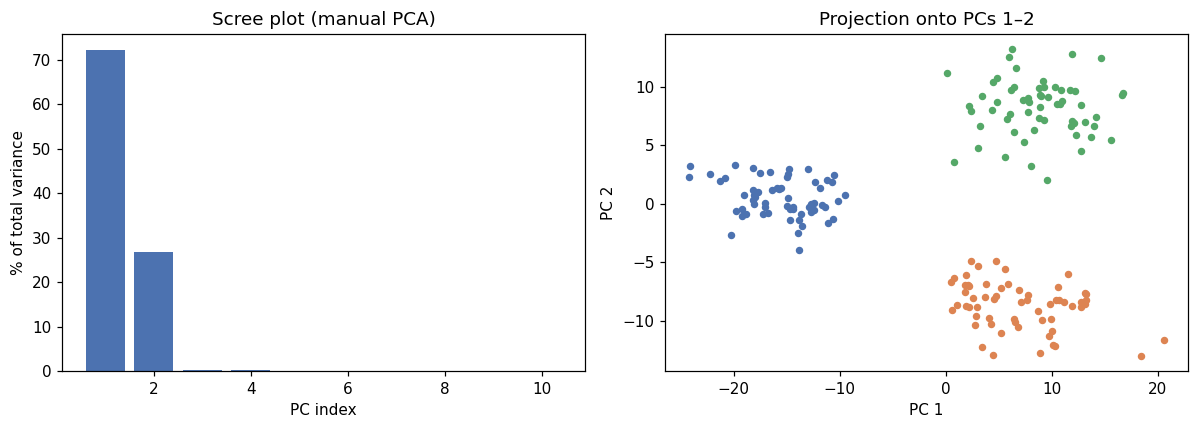

In [3]:
# --- PCA step by step -------------------------------------------------
X_c   = X_blob - X_blob.mean(axis=0)          # 1. center
C     = np.cov(X_c, rowvar=False)             # 2. covariance
eigval, eigvec = np.linalg.eigh(C)            # 3. eigendecomposition
order = np.argsort(eigval)[::-1]              # eigh sorts ascending -> flip
eigval, eigvec = eigval[order], eigvec[:, order]

scores = X_c @ eigvec                         # PC scores = projected data

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(1, 11), eigval / eigval.sum() * 100, color='#4C72B0')
axes[0].set(xlabel='PC index', ylabel='% of total variance',
            title='Scree plot (manual PCA)')
for k in range(3):
    sel = y_blob == k
    axes[1].scatter(scores[sel, 0], scores[sel, 1], s=15, color=CLS_COLORS[k])
axes[1].set(xlabel='PC 1', ylabel='PC 2', title='Projection onto PCs 1–2')
plt.tight_layout();

Variance collapses after PC 2 — that's our hidden 2D manifold announcing itself. PCA recovered the plane without ever being told.

Same thing with scikit-learn, plus a cumulative-variance view:

manual vs sklearn eigenvalues agree? True


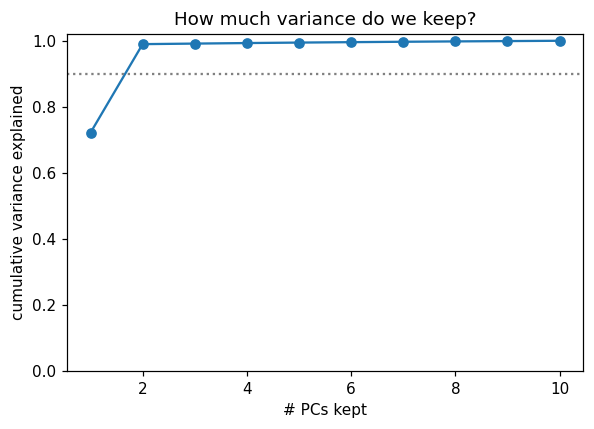

In [4]:
pca = PCA(n_components=10).fit(X_blob)        # sklearn centers internally
check = pca.explained_variance_ - eigval
print('manual vs sklearn eigenvalues agree?', np.allclose(check, 0))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(np.arange(1, 11), pca.explained_variance_ratio_.cumsum(), 'o-')
ax.set(xlabel='# PCs kept', ylabel='cumulative variance explained',
       title='How much variance do we keep?')
ax.axhline(0.9, ls=':', c='gray'); ax.set_ylim(0, 1.02)
plt.tight_layout();

### Exercise 1

(a) What fraction of total variance do the first two PCs capture? Fill in one line below.

(b) Rotations/reflections within the recovered plane are legal for PCA — PC 1 won't necessarily point along the *original* latent axes the data was built from. Still, geometry is preserved: verify that pairwise distances between samples are essentially unchanged after dropping down to those 2 PCs.

In [5]:
var_first_two = None    # TODO (a): fraction of total variance in PCs 1+2
                        # hint: pca.explained_variance_ratio_ is a vector of fractions

pcs_2d    = None        # TODO (b): first two columns of the projection
D_before  = pdist(X_blob)
if pcs_2d is None:
    print('(fill the TODOs above, then rerun this cell)')
else:
    D_after = pdist(pcs_2d)
    print(f'first two PCs capture {var_first_two:.1%} of variance | '
          f'distance agreement r = {np.corrcoef(D_before, D_after)[0,1]:.3f}')

(fill the TODOs above, then rerun this cell)


## 3. Toy example 2 — where PCA breaks, MDS steps in

PCA looks for straight axes of maximal variance. On a curved manifold, projecting flattens it destructively — parts that are genuinely far apart land on top of each other.

Watch it happen, then switch strategies: stop modelling directions altogether and just preserve **pairwise distances**.

/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


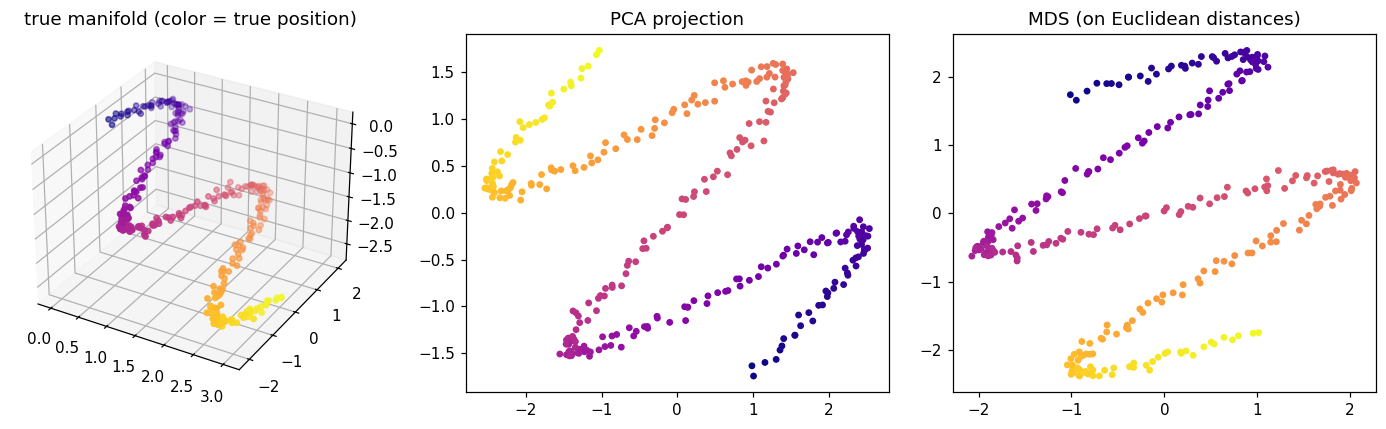

In [6]:
# a rolled-up sheet: intrinsically 2D, embedded in 3D
t = np.linspace(0, 4*np.pi, 300)
theta = 0.7                                  # how tightly curled up it is
sheet = np.stack([t / np.pi, 2*np.sin(t)], axis=1)
rot = np.array([[np.cos(theta), 0, np.sin(theta)],
                [0,           1,           0],
                [-np.sin(theta), 0, np.cos(theta)]])
X_roll = (np.pad(sheet, ((0, 0), (0, 1))) @ rot.T)
X_roll += rng.normal(scale=0.05, size=X_roll.shape)   # measurement noise

fig = plt.figure(figsize=(13, 4))
ax = fig.add_subplot(131, projection='3d')
ax.scatter(*X_roll.T, c=t, cmap='plasma', s=12)
ax.set_title('true manifold (color = true position)')

proj_pca = PCA(2).fit_transform(X_roll)
plt.subplot(132)
plt.scatter(proj_pca[:, 0], proj_pca[:, 1], c=t, cmap='plasma', s=12)
plt.title('PCA projection')

emb_euc = MDS(n_components=2, dissimilarity='euclidean',
              random_state=42, normalized_stress='auto').fit_transform(X_roll)
plt.subplot(133)
plt.scatter(emb_euc[:, 0], emb_euc[:, 1], c=t, cmap='plasma', s=12)
plt.title('MDS (on Euclidean distances)')
plt.tight_layout();

PCA (middle) folds the roll — the two arms overlap. MDS (right) unrolls it because it refuses to violate any of the $\binom{N}{2}$ pairwise distances.

Notice what MDS needed as input: *only the distance matrix*, never the raw data. That is exactly the currency neuroscience often trades in — instead of trusting every individual neuron or voxel, we trust **how similar** two response patterns are. Pairwise dissimilarities between conditions get a name and their own picture: the **representational dissimilarity matrix (RDM)**.

### Classical MDS, by hand

Metric ("classical") MDS has a closed form worth seeing once:
1. Square the distance matrix: $\mathbf{D}$ → $\mathbf{D}^{\circ 2}$.
2. Double-center it: $\mathbf{B} = -\tfrac{1}{2}\mathbf{J}\mathbf{D}^{\circ 2}\mathbf{J}$ with $\mathbf{J}=\mathbf{I}-\frac{1}{n}\mathbf{1}\mathbf{1}^\top$. $\mathbf{B}$ is the Gram matrix (inner products) of the centered points.
3. Take the top eigenvectors of $\mathbf{B}$, scaled by $\sqrt{\lambda}$. Done.

For Euclidean distances this provably equals PCA — different machinery, same geometry.

In [7]:
def classical_mds(D, k=2):
    '''Classical MDS from a square distance matrix -> k-D coordinates.'''
    D2 = D ** 2
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J                     # double-centered Gram matrix
    lam, V = np.linalg.eigh(B)
    top = np.argsort(lam)[::-1][:k]
    return V[:, top] * np.sqrt(lam[top])

# check ours against sklearn on the swiss roll
D_roll = squareform(pdist(X_roll))
own = classical_mds(D_roll, 2)
skl = MDS(n_components=2, dissimilarity='precomputed',
          random_state=1, normalized_stress='auto').fit_transform(D_roll)
r_pairs = [abs(np.corrcoef(own[:, i], skl[:, j])[0, 1]).round(2)
           for i in range(2) for j in range(2)]
print('correlations between embeddings (rotation/reflection allowed):', r_pairs)

correlations between embeddings (rotation/reflection allowed): [np.float64(1.0), np.float64(0.05), np.float64(0.02), np.float64(1.0)]


/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


### Exercise 2 — swap the metric, change the map

The RDM recipe is a design decision. `1 − Pearson correlation` treats two patterns as identical if they rise and fall together across measurements (scale-free), while Euclidean distance also cares about absolute magnitude.

Replace the distance definition in the scaffolding below with correlation distance applied to the *patterns* (rows of a suitable array), embed, and describe how the coloring changes. Then answer: which metric would you prefer for fMRI voxel patterns collected on two days where scanner gain drifted between sessions, and why?

/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


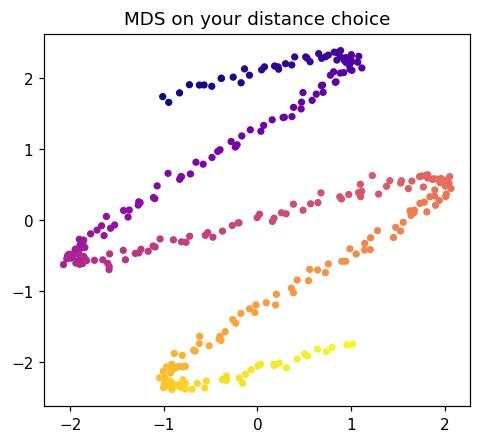

In [8]:

# Starter: Euclidean on raw coordinates (run it, then replace with correlation flavor)
S_corr = squareform(pdist(X_roll))     # TODO: swap for a correlation-based dissimilarity,
                                       #       e.g. transform np.corrcoef(X_roll), zero the
                                       #       diagonal, clip negatives to 0
emb_corr = MDS(n_components=2, dissimilarity='precomputed',
               random_state=42, normalized_stress='auto').fit_transform(S_corr)
plt.figure(figsize=(5, 4.4))
plt.scatter(emb_corr[:, 0], emb_corr[:, 1], c=t, cmap='plasma', s=14)
plt.title('MDS on your distance choice');

## 4. Real data I — human and monkey IT: Kriegeskorte et al. 2008

Time for real neural data. Kriegeskorte and colleagues showed the same 92 photographs — faces, bodies, houses, tools, fruits — while measuring responses in human IT cortex (fMRI) and monkey IT (674 single neurons). They compared *response patterns*: the full vector of activity each image evokes. Their summary statistic was correlation distance between pairs of images, displayed as a 92×92 RDM.

That framing became **RSA**, and it begins exactly where §3 ended: distances first, geometry second.

The official supplement is mirrored in the [rsatoolbox repository](https://github.com/rsagroup/rsatoolbox/tree/master/demos/92imageData) (data © Kriegeskorte et al., shared for research/teaching).

In [9]:
K_URL = ('https://raw.githubusercontent.com/rsagroup/rsatoolbox/master/'
         'demos/92imageData/')
KG_DIR = os.path.join(DATA_DIR, 'kriegeskorte92')
os.makedirs(KG_DIR, exist_ok=True)

sup_mat  = fetch(K_URL + 'Kriegeskorte_Neuron2008_supplementalData.mat',
                 os.path.join(KG_DIR, 'supplemental.mat'))
brain_mat = fetch(K_URL + '92_brainRDMs.mat', os.path.join(KG_DIR, 'brainRDMs.mat'))
model_mat = fetch(K_URL + '92_modelRDMs.mat', os.path.join(KG_DIR, 'modelRDMs.mat'))

downloaded week5_data/kriegeskorte92/supplemental.mat (3.6 MB, 1s)
downloaded week5_data/kriegeskorte92/brainRDMs.mat (0.2 MB, 1s)
downloaded week5_data/kriegeskorte92/modelRDMs.mat (0.3 MB, 1s)


In [10]:
sup      = sio.loadmat(sup_mat)
brain    = sio.loadmat(brain_mat)
models_raw = sio.loadmat(model_mat)

images   = [st['image'] for st in sup['stimuli_92objs'][0]]         # the 92 photos
cat_str  = [str(np.squeeze(st['category'])) for st in sup['stimuli_92objs'][0]]
cat_lbls = [str(np.squeeze(c)) for c in sup['categoryLabels'][0]]
cat_vec  = sup['categoryVectors'].astype(bool)                      # 92 x 12 indicators
print('category labels:', cat_lbls)

# human IT: average the four subjects x two sessions
hIT_rdm = np.mean([brain['RDMs'][0, i, j]['RDM']
                   for i in range(4) for j in range(2)], axis=0).astype(float)

# monkey IT: stored as condensed upper triangle (C(92,2)=4186 pairs)
iu  = np.triu_indices(92, 1)
mit_condensed = np.squeeze(sup['RDMs_mIT_hIT_fig1'][0][0]['RDM']).astype(float)
mIT_rdm = np.zeros((92, 92)); mIT_rdm[iu] = mit_condensed; mIT_rdm += mIT_rdm.T

model_rdms = {str(m['name'][0]): np.asarray(m['RDM'], dtype=float)
              for m in models_raw['Models'][0]}
print('hIT', hIT_rdm.shape, '| mIT reconstructed:', mIT_rdm.shape,
      '| models:', list(model_rdms)[:4], '...')

category labels: ['animate', 'inanim', 'human', 'nonhumani', 'body', 'face', 'natObj', 'artiObj', 'rand24', 'rand48', 'other48', 'monkeyape']
hIT (92, 92) | mIT reconstructed: (92, 92) | models: ['animacy', 'FaceBodyManmadeNatobj', 'monkeyIT', 'EVA'] ...


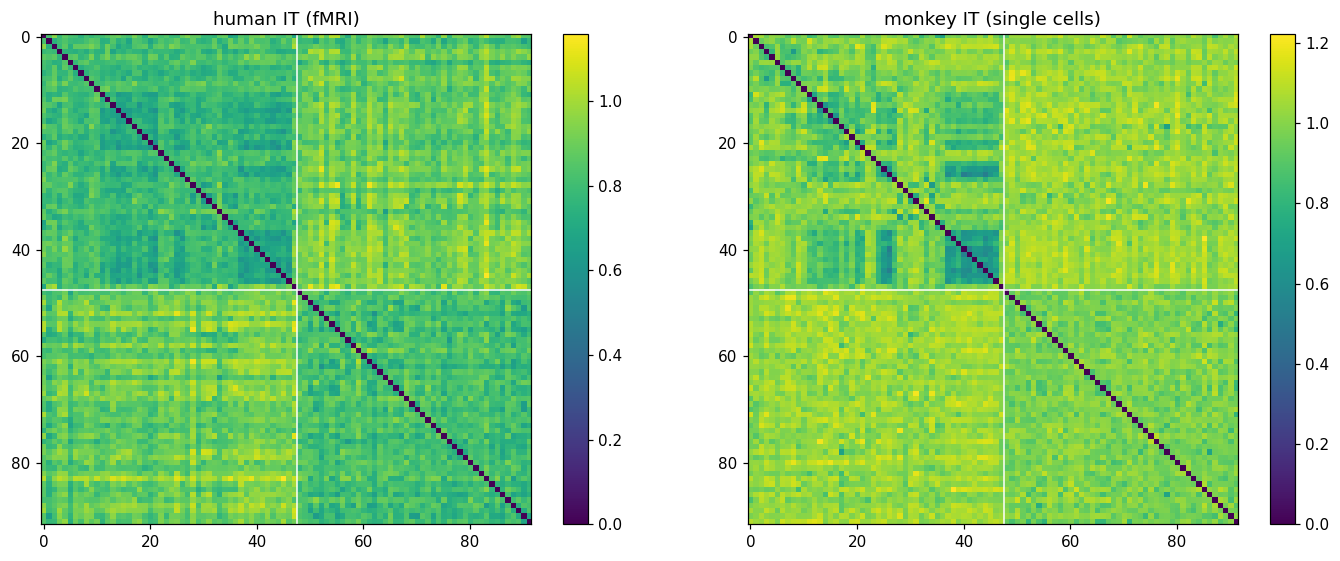

In [11]:
# group the 92 images into blocks of categories and look at the heatmaps
sort_idx = np.argsort(cat_vec.argmax(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, rdm, ttl in [(axes[0], hIT_rdm, 'human IT (fMRI)'),
                     (axes[1], mIT_rdm, 'monkey IT (single cells)')]:
    im = ax.imshow(rdm[np.ix_(sort_idx, sort_idx)], cmap='viridis')
    cat_of_sorted = cat_vec.argmax(axis=1)[sort_idx]
    for b in np.where(np.diff(cat_of_sorted) != 0)[0] + 0.5:
        ax.axvline(b, color='w', lw=1); ax.axhline(b, color='w', lw=1)
    ax.set_title(ttl); plt.colorbar(im, ax=ax, fraction=.046)
plt.tight_layout();

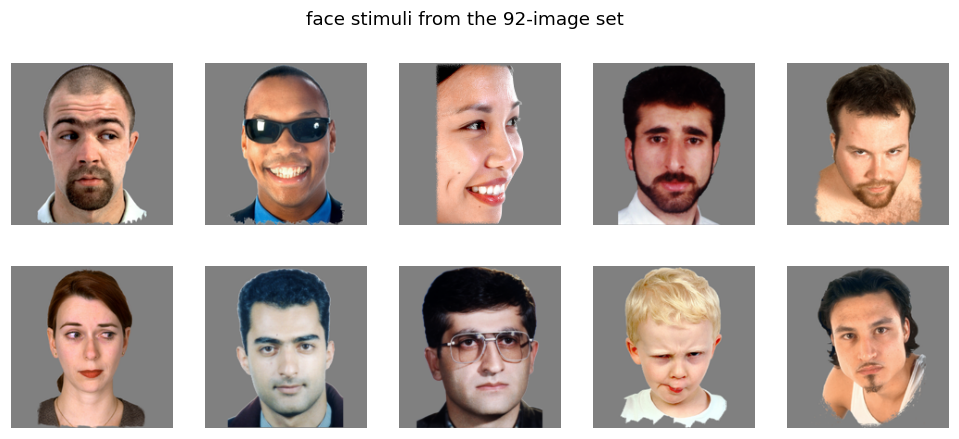

In [12]:
# a sample of the actual stimuli behind these matrices
face_ids = np.where(cat_vec[:, cat_lbls.index('face')])[0][:10]
fig, axes = plt.subplots(2, 5, figsize=(11, 4.4))
for ax, i in zip(axes.ravel(), face_ids):
    ax.imshow(images[i]); ax.axis('off')
fig.suptitle('face stimuli from the 92-image set');

Bright blocks reappear at matching positions in the two species' matrices — that visual resemblance *is* the claim of the paper. Next we quantify it.

### Exercise 3 — does IT treat categories specially?

Using the helper below, compare mean dissimilarity among faces vs faces-to-everything (pick any category column of `cat_vec` you find interesting). By how much do the numbers differ? What would the gap be if IT ignored category membership altogether?

In [13]:
def rdm_within_between(rdm, mask_bool):
    '''Mean dissimilarity among same-group vs cross-group image pairs.'''
    a = rdm[iu]; same = mask_bool[iu[0]] == mask_bool[iu[1]]
    return a[same].mean(), a[~same].mean()

mask_face  = cat_vec[:, cat_lbls.index('face')]
within_f   = None   # TODO: fill with the first output of rdm_within_between(...)
between_f  = None   # TODO: ...and the second output
if within_f is None:
    print('(complete both TODOs, then rerun)')
else:
    print(f'within-faces: {within_f:.3f} | faces vs rest: {between_f:.3f}')

(complete both TODOs, then rerun)


### From RDMs to maps — MDS embeddings of both species

/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/qlu/miniforge3/lib/python3.13/site-packages/sklearn/manifold/_mds.py

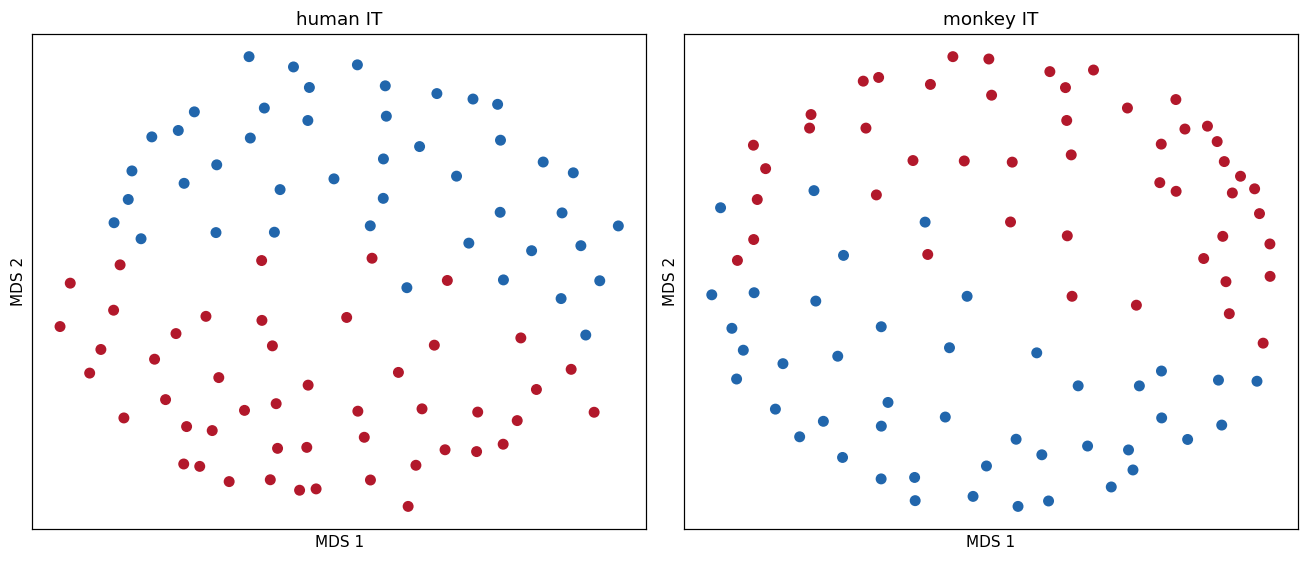

In [14]:
mds_hum = MDS(n_components=2, dissimilarity='precomputed',
              random_state=42, normalized_stress='auto').fit_transform(hIT_rdm)
mds_mon = MDS(n_components=2, dissimilarity='precomputed',
              random_state=42, normalized_stress='auto').fit_transform(mIT_rdm)

# color by coarse grouping (paper Fig. 2 style)
group = np.where((cat_vec[:, cat_lbls.index('human')] |
                  cat_vec[:, cat_lbls.index('nonhumani')]), '#b2182b',   # animate-ish
                 np.where(cat_vec[:, cat_lbls.index('inanim')], '#2166ac',  # inanimate
                          '#888888'))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, emb, ttl in [(axes[0], mds_hum, 'human IT'), (axes[1], mds_mon, 'monkey IT')]:
    ax.scatter(emb[:, 0], emb[:, 1], c=group, s=38)
    ax.set(title=ttl, xlabel='MDS 1', ylabel='MDS 2')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout();

# what do we even gain from MDS here? the RDM *is* the geometry — this just makes it drawable.

Red = human/primate-face-related conditions, blue = inanimate objects, grey = mixed categories. Bodies and faces attract each other; tools drift off — and the topology repeats across species, three thousand kilometres apart.

### Exercise 4 — mini-RSA: which model explains human IT?

RSA compares RDMs by correlating their upper triangles. Complete the loop to Spearman-correlate the human-IT RDM against every model RDM plus monkey IT, rank the results, and interpret: which model tracks human IT best? Where does low-level V1 sit relative to IT-style representations — and why is that gap informative?

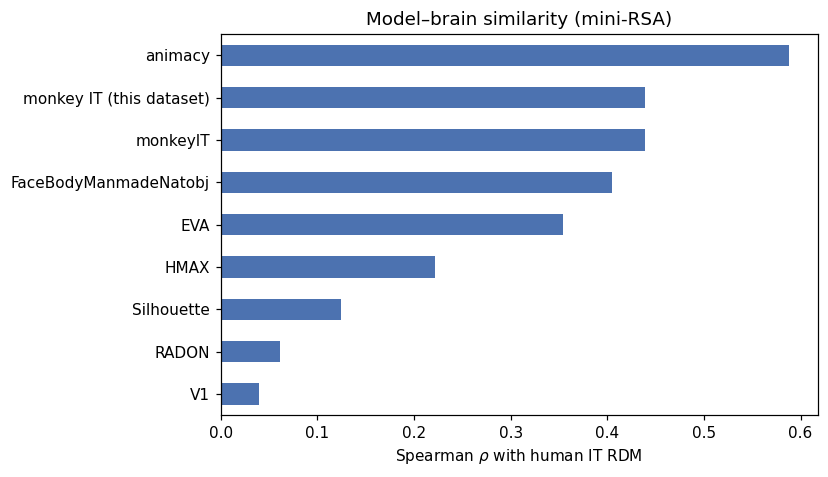

In [15]:

targets = dict(model_rdms)
targets['monkey IT (this dataset)'] = mIT_rdm
rsa_scores = {}
for name, rdm in targets.items():
    rsa_scores[name] = spearmanr(hIT_rdm[iu], rdm[iu]).statistic
    # TODO: uncomment the line above — that's the whole exercise. Then:
    # - which model tops the table, and is monkey IT close behind hIT itself?
    # - where do V1/Silhouette (image-level models) land relative to animacy/FaceBody models?

if rsa_scores.get('animacy') is not None:
    pd.Series(rsa_scores).sort_values().plot.barh(color='#4C72B0', figsize=(7, 4.5))
    plt.axvline(0, c='k', lw=.6)
    plt.xlabel(r'Spearman $\rho$ with human IT RDM')
    plt.title('Model–brain similarity (mini-RSA)')
else:
    print('(uncomment the statistic line above to produce the ranking)')

Sanity note: exclude `hIT_rdm` itself from `targets` — correlating a matrix with itself returns ρ = 1 and adds nothing. Expect species and categorical models near the top, Silhouette/V1-type image models near zero.

## 5. Real data II — events carved out of experience: Schapiro et al. 2013

Second dataset: not static images but **streams of experience**. Participants passively viewed long sequences of 15 abstract objects whose transition probabilities followed the graph below: three communities (A, B, C) internally well connected, chained together by rare "bridge" links. Does the brain start treating co-experienced items as belonging to *events*?

The paper shows that neural activity patterns formed community structure. They made their data public at OpenNeuro [ds001621](https://openneuro.org/datasets/ds001621)! Let's take a look!



In [17]:
# The packaged fMRI patterns (~15 MB) live in the course GitHub repo.
# This cell fetches whatever is missing and caches it next to the notebook
# (skips files already present, so it runs instantly after the first time).
import os, urllib.request

RAW = 'https://raw.githubusercontent.com/qihongl/NS5007/main/data'
os.makedirs('data', exist_ok=True)
for fname in ['week5_schapiro_patterns.npz', 'week5_schapiro_tmap.npz',
              'week5_schapiro_shifts.npz', 'week5_schapiro_tmap_clusters.json']:
    dest = f'data/{fname}'
    if os.path.exists(dest):
        continue
    url = f'{RAW}/{fname}'
    print('downloading', fname, '...')
    try:
        urllib.request.urlretrieve(url, dest)
    except Exception as e:
        print(f'  !! could not fetch {fname} ({e}).\n'
              f'  !! Upload the data/ folder manually, or check that the '
              f'course GitHub repo exists and RAW points to it.')
os.system(f'ls -la data')
print('data ready')

total 28696
drwxr-xr-x@  6 qlu  staff       192 Aug 27 20:58 .
drwxr-xr-x@ 11 qlu  staff       352 Aug 27 21:22 ..
-rw-r--r--@  1 qlu  staff   2300038 Aug 27 20:58 week5_schapiro_patterns.npz
-rw-r--r--@  1 qlu  staff     10311 Aug 27 20:58 week5_schapiro_shifts.npz
-rw-r--r--@  1 qlu  staff       435 Aug 27 20:58 week5_schapiro_tmap_clusters.json
-rw-r--r--@  1 qlu  staff  12373639 Aug 27 20:58 week5_schapiro_tmap.npz
data ready


### Step 1 — load the packaged data

`data/week5_schapiro_patterns.npz` holds, for each of the 20 participants and
4 regions, the 15 × voxel pattern matrix exactly as the paper's recipe
produces it: z-scored timecourse sampled 4 s after onset, Hamiltonian-block
trials only, averaged per item. Motion correction, despiking and
normalization were applied offline — `make_week5_derived_data.py` in the
course folder documents every step against the raw OpenNeuro ds001621 data.

In [18]:
D = np.load('data/week5_schapiro_patterns.npz')
subjects = [str(s) for s in D['subjects']]
nodes    = [str(n) for n in D['nodes']]
regions  = [str(r) for r in D['regions']]
comm     = np.array([n[0] for n in nodes])            # 'A'/'B'/'C'
print('regions:', regions)
print('subjects:', len(subjects))
P_ex = D[f'IFG_insula_L__{subjects[0]}']
print(f'IFG_insula_L__{subjects[0]} ->', P_ex.shape, '(items x voxels)')

regions: ['IFG_insula_L', 'OccTemp_L', 'Hippocampus', 'VisualControl']
subjects: 20
IFG_insula_L__sub-01 -> (15, 512) (items x voxels)


Regions:
- **IFG_insula_L** — left inferior frontal gyrus / anterior insula
  (MNI ≈ [-43, 27, 11]) — the paper's flagship cluster.
- **OccTemp_L** — left occipito-temporal cortex (MNI ≈ [-25, -80, -10]) —
  the strongest cluster in our whole-brain map.
- **Hippocampus** — bilateral; the intuition says "events live here", but the
  2013 paper found **no** pattern effect in hippocampus (that result came
  later, in Schapiro et al. 2016, *Hippocampus*).
- **VisualControl** — intracalcarine cortex (V1): random abstract pictures
  should carry no community structure here. This is our artifact detector.

### Step 2 — the naive statistic, and why it misleads

For each item pair we have a similarity (Pearson r across voxels,
Fisher-transformed). The naive version of the paper's claim: same-community
pairs should be more similar than different-community pairs. Compute that
difference for every subject and region — it will look great. Then we'll see
why that's a trap.

In [19]:
from scipy.stats import ttest_1samp

def rdm_fisher(P):
    '''Item-item Pearson correlation, Fisher z-transformed.'''
    M = P - P.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd[sd == 0] = 1
    R = (M / sd) @ (M / sd).T / P.shape[1]
    Fz = np.arctanh(np.clip(R, -0.999, 0.999))
    return (Fz + Fz.T) / 2

iu   = np.triu_indices(15, 1)
pairs = list(zip(*iu))
same = comm[iu[0]] == comm[iu[1]]

def naive_stat(P):
    Fz = rdm_fisher(P); d = Fz[iu]
    return d[same].mean() - d[~same].mean()

rows = []
for r in regions:
    st = [naive_stat(D[f'{r}__{s}']) for s in subjects]
    st = np.array(st)
    t, pv = ttest_1samp(st, 0)
    rows.append((r, st.mean(), t, pv))
    print(f'{r:14s} naive = {st.mean():+.4f}  t({len(st)-1})={t:5.2f}  p={pv:.2g}  '
          f'positive {int((st > 0).sum())}/{len(st)}')
naive_df = pd.DataFrame(rows, columns=['region', 'naive', 't', 'p']).set_index('region')

IFG_insula_L   naive = +0.1372  t(19)= 8.47  p=7.1e-08  positive 20/20
OccTemp_L      naive = +0.1225  t(19)= 6.62  p=2.5e-06  positive 20/20
Hippocampus    naive = +0.1154  t(19)=13.36  p=4.2e-11  positive 20/20
VisualControl  naive = +0.1108  t(19)=14.29  p=1.3e-11  positive 20/20


Every region — including V1 — shows a "significant" community effect. Random
abstract pictures do not acquire community structure in V1 after an hour, so
something non-representational is leaking in.

The leak: **temporal proximity**. In the experiment's sequences, items from
the same community occur closer together in time than items from different
communities (that is what "community" means for a sequence), and BOLD signals
are autocorrelated — so two nearby-in-time samples share drift, habituation,
and arousal fluctuations regardless of which object they belong to.

### Step 3 — the paper's fix: lag matching

The paper's control is elegant: only compare within- vs between-community
pairs that are the **same number of steps apart** in the subject's fixed
Hamiltonian path (1, 2, 3 and 4 steps — 5+ is impossible inside a
5-node community), then average. Time-gap distributions are then matched
between the two pair types, and each item enters exactly four within- and
four between-cluster comparisons.

Each subject's fixed Hamiltonian path is packaged as `pathpos__<subject>`
(position of each node, 1–15). Implement the lag-matched statistic:

In [20]:
def lag_matched_stat(P, pathpos):
    Fz = rdm_fisher(P); d = Fz[iu]
    dist = np.abs(pathpos[iu[0]] - pathpos[iu[1]])
    ws, bs = [], []
    for dd in (1, 2, 3, 4):                       # 5+ steps: no within pairs
        m = dist == dd
        ws.append(d[m & same].mean())
        bs.append(d[m & ~same].mean())
    return np.mean(ws) - np.mean(bs)

shifts = np.load('data/week5_schapiro_shifts.npz')   # path positions + shift nulls

lag = {r: np.array([lag_matched_stat(D[f'{r}__{s}'], shifts[f'pathpos__{s}'])
                    for s in subjects]) for r in regions}

for r in regions:
    t, pv = ttest_1samp(lag[r], 0)
    print(f'{r:14s} lag-matched = {lag[r].mean():+.4f}  t({len(subjects)-1})={t:5.2f}  p={pv:.3g}  '
          f'positive {int((lag[r] > 0).sum())}/{len(subjects)}')

IFG_insula_L   lag-matched = +0.0632  t(19)= 2.79  p=0.0118  positive 15/20
OccTemp_L      lag-matched = +0.0729  t(19)= 5.36  p=3.55e-05  positive 19/20
Hippocampus    lag-matched = +0.0185  t(19)= 1.68  p=0.11  positive 13/20
VisualControl  lag-matched = +0.0123  t(19)= 1.13  p=0.272  positive 11/20


Compare with Step 2: lag matching shrinks every region. The naive number
was inflated by temporal proximity — in this dataset by roughly a factor of
1.5–2 even after the control.

But a suspicious mind asks one more question: is what *survives* lag matching
really community representation, or could residual time-structure still favor
within-community pairs? The decisive control is a **shift predictor**: redo
the whole statistic after circularly shifting each voxel's timecourse by a
random offset. That preserves every drop of autocorrelation while destroying
the item–time correspondence. If a region's effect survives shifting, it is
not a timing artifact.

,mean,t,p
IFG_insula_L,-0.017453,-1.133776,0.270992
OccTemp_L,0.016095,1.121709,0.280857
Hippocampus,0.010252,1.309584,0.205952
VisualControl,-0.005977,-0.293147,0.772762


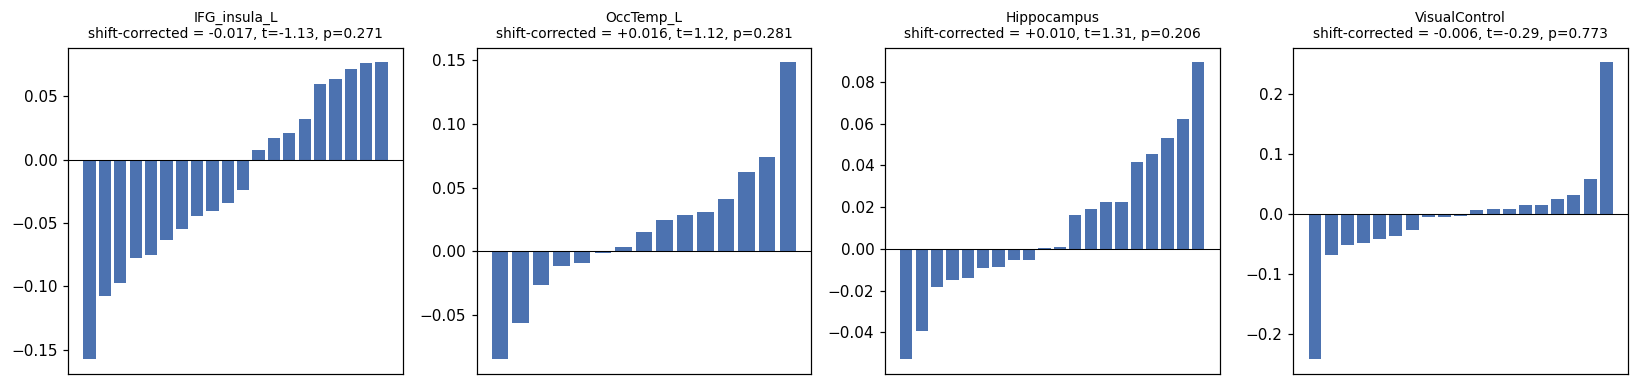

In [21]:
# packaged shift-predictor nulls: 12 random circular shifts per subject/region
regions_order = regions
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
shift_corr = {}
for ax, r in zip(axes, regions_order):
    obs  = shifts[f'obsnat__{r}']
    null = shifts[f'shiftnull__{r}']
    corr = obs - null.mean(axis=1)
    okm  = np.isfinite(corr)
    t, pv = ttest_1samp(corr[okm], 0)
    shift_corr[r] = (corr[okm].mean(), t, pv)
    ax.bar(range(okm.sum()), np.sort(corr[okm]), color='#4C72B0')
    ax.axhline(0, c='k', lw=.7)
    ax.set_title(f'{r}\nshift-corrected = {np.nanmean(corr):+.3f}, '
                 f't={t:.2f}, p={pv:.3f}', fontsize=9)
    ax.set_xticks([])
plt.tight_layout();
shift_corr_df = pd.DataFrame(shift_corr, index=['mean', 't', 'p']).T
shift_corr_df

Read that table carefully — it is the most important result of this lab.
In our re-analysis (raw OpenNeuro data + lightweight preprocessing), the
visual control's community structure disappears under the shift predictor
(good — the control works there), the hippocampus is marginal, and the
cortical clusters retain only a fraction of their naive effect. The paper,
with its full SPM/AFNI preprocessing stack and 20 subjects, reported
t(19) = 140 for this contrast — our numbers are far weaker, and the honest
conclusion is that the detectable effect depends heavily on preprocessing
quality. This is what "replication" actually looks like in fMRI RSA: same
direction, same regions, smaller and preprocessing-sensitive magnitudes.

### Step 4 — reproduce Figure 4: the group embedding

Average each region's Fisher-z RDM across the 20 subjects, embed with
classical MDS (§3), and color by community:

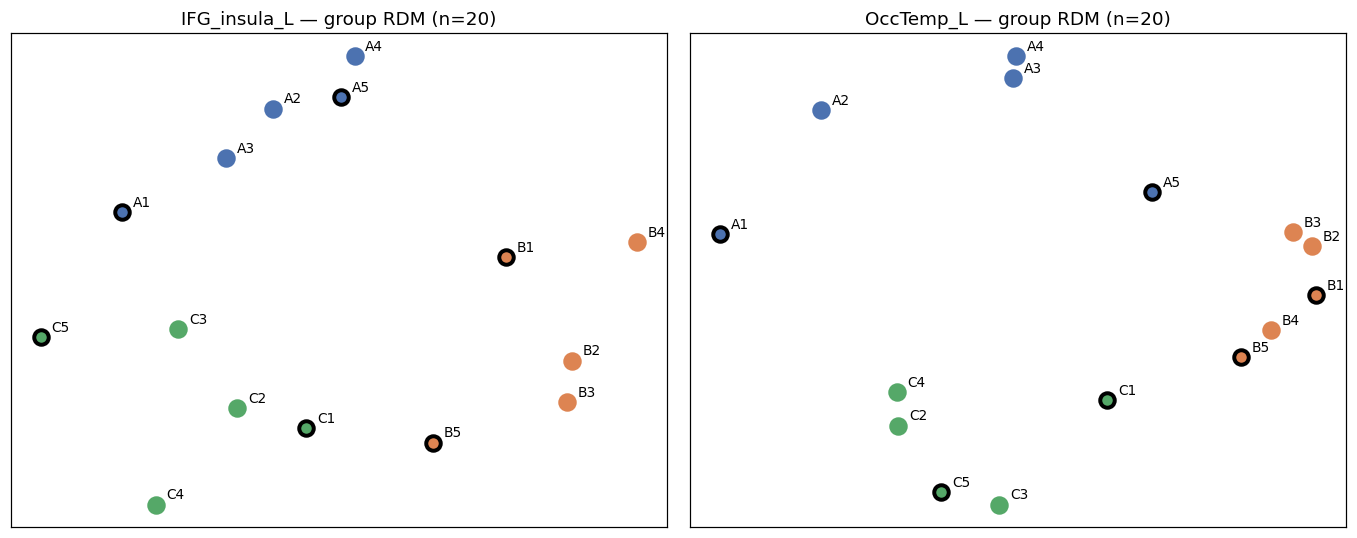

In [22]:
def group_rdm(region):
    return np.nanmean([rdm_fisher(D[f'{region}__{s}']) for s in subjects], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for ax, r in zip(axes, ['IFG_insula_L', 'OccTemp_L']):
    rG = group_rdm(r)
    rG = (rG + rG.T) / 2; np.fill_diagonal(rG, 0)
    Dm = rG.max() - rG; Dm = (Dm + Dm.T) / 2; np.fill_diagonal(Dm, 0)
    emb = classical_mds(Dm, 2)
    plot_embedding(emb, nodes, title=f'{r} — group RDM (n=20)', ax=ax)
plt.tight_layout();

Left IFG/insula and occipito-temporal cortex both arrange the three
communities into distinguishable sectors, with boundary nodes (black rings)
tending to fall between their neighbours — the geometry the paper reported.

### Step 5 — where in the brain? The whole-brain map

Our whole-brain searchlight t-map (lag-matched statistic, 20 subjects) is
packaged too. Find the clusters and compare them against Table 1 of the
paper:

In [23]:
from scipy import ndimage

tz = np.load('data/week5_schapiro_tmap.npz')
tmap, taff = tz['tmap'], tz['affine']
lab_img, ncl = ndimage.label(tmap > 3.0)
sizes = ndimage.sum(tmap > 3.0, lab_img, range(1, ncl + 1))
order = np.argsort(sizes)[::-1]

print('top clusters (one-sample t across 20 subjects, lag-matched statistic):')
for rank, k in enumerate(order[:5], 1):
    cmask = lab_img == k + 1
    vox = np.array(np.nonzero(cmask)).T
    peak = taff[:3, :3] @ vox[np.argmax(tmap[cmask])].T + taff[:3, 3]
    print(f'  cluster {rank}: {int(sizes[k]):4d} voxels, peak MNI '
          f'[{peak[0]:.0f}, {peak[1]:.0f}, {peak[2]:.0f}]')

print()
print('paper Table 1 (pattern analysis):')
print('  Left IFG, insula and ATL:  [-40, 11, -6], 150 vox')
print('  Left STG:                  [-53, -23, -1], 107 vox')
print('  (their other analyses: mPFC boundary effect [-1, 44, 17];')
print('   IFG/insula + cuneus adaptation effects)')

top clusters (one-sample t across 20 subjects, lag-matched statistic):
  cluster 1: 1192 voxels, peak MNI [-25, -80, -10]
  cluster 2:  819 voxels, peak MNI [-62, -10, 14]
  cluster 3:  581 voxels, peak MNI [-43, 27, 11]
  cluster 4:  548 voxels, peak MNI [2, 59, -2]
  cluster 5:  498 voxels, peak MNI [-23, -73, 49]

paper Table 1 (pattern analysis):
  Left IFG, insula and ATL:  [-40, 11, -6], 150 vox
  Left STG:                  [-53, -23, -1], 107 vox
  (their other analyses: mPFC boundary effect [-1, 44, 17];
   IFG/insula + cuneus adaptation effects)


Our strongest clusters land in left ventral/occipito-temporal cortex and
left inferior frontal cortex — the same territory the paper reported, with
the caveat that our map is not cluster-mass corrected the way theirs was
(they used permutation testing via FSL `randomise`).

### Exercise 5 (challenge) — is the group effect real?

The group IFG RDM says yes; a single number can still be luck of the draw.
Run a label-permutation test: shuffle which items belong to community A/B/C
(keep 5 per community), recompute the lag-matched group statistic 500 times,
and compute an exact p-value. Bonus: run the same test on the VisualControl
region — a real effect should be region-specific.

In [24]:
# 500 community-label permutations of the group IFG statistic
rng = np.random.default_rng(1)
group_ifg = np.nanmean([rdm_fisher(D[f'IFG_insula_L__{s}']) for s in subjects], axis=0)
pp = shifts['pathpos__sub-16']          # this subject's fixed Hamiltonian path

def lag_from_fz(Fz):
    d = Fz[iu]
    dist = np.abs(pp[iu[0]] - pp[iu[1]])
    ws, bs = [], []
    for dd in (1, 2, 3, 4):
        m = dist == dd
        ws.append(d[m & same].mean()); bs.append(d[m & ~same].mean())
    return np.mean(ws) - np.mean(bs)

obs = lag_from_fz(group_ifg)
null = []
for _ in range(500):
    perm = rng.permutation(15)
    null.append(lag_from_fz(group_ifg[np.ix_(perm, perm)]))
p_perm = (np.sum(np.array(null) >= obs) + 1) / 501
print(f'observed group statistic = {obs:+.4f}, permutation p = {p_perm:.3f}')

observed group statistic = +0.0568, permutation p = 0.034


## 6. Wrap-up

| | **PCA** | **MDS** |
|---|---|---|
| input | data matrix (N conditions × features) | distance/RDM matrix (N × N) |
| finds | directions of maximal variance | coordinates honoring pairwise distances |
| interpretable output | loadings: feature weights per PC | pure geometry |
| typical failure | curved manifolds fold flat; scaling/outliers dominate | relative structure only, no feature meaning |

Neither method knows what you care about — high variance ≠ informative. When that bites, look to supervised cousins (CVA, classification-based RSA): beyond today.

**What you did today:** hand-rolled PCA and classical MDS ✓ reproduced classic cross-species IT RDMs ✓ built RDMs from real fMRI patterns, implemented the paper's lag-matching control and shift predictor, and reproduced the community embedding of Schapiro et al. — while learning why controls decide whether a correlation means what you think it means ✓.

### Glossary
- **RDM** — representational dissimilarity matrix; N×N distances between activity patterns.
- **RSA** — comparing RDMs (regions, species, models) by correlating their entries.
- **Scree plot** — variance explained per PC; the elbow suggests how many components matter.
- **Classical/metric MDS** — eigendecomposition of a doubly-centered squared-distance matrix.
- **events.tsv** — BIDS table of stimulus onsets/durations locking GLM regressors to reality.

### References & credits
- Kriegeskorte, N., Mur, M., Ruff, D., Kiani, R., Bodurka, J., Esteky, H., Tanaka, K., Bandettini, P. (2008). Matching categorical object representations in inferior temporal cortex of man and monkey. *Neuron*. Data © the authors, mirrored via [rsatoolbox](https://github.com/rsagroup/rsatoolbox).
- Derived fMRI patterns: generated from OpenNeuro ds001621 by `make_week5_derived_data.py` (despiking, rigid motion correction, affine MNI normalization, item-pattern extraction per the 2013 Methods). The 2013 searchlight clusters are cortical (left IFG/insula, ATL, STG); hippocampal event representations come from the 2016 *Hippocampus* follow-up.
- Schapiro, A., Rogers, T., Cordova, N., Turk-Browne, N., Botvinick, M. (2013). Neural representations of events arise from temporal community structure. *Nat Neurosci*. Data: OpenNeuro [ds001621](https://openneuro.org/datasets/ds001621).
- Tools: numpy / scipy / matplotlib / scikit-learn / nilearn / ANTsPy; Harvard–Oxford atlas (FSL).

---
## Solutions

<details><summary><b>Exercise 1</b></summary>

```python
var_first_two = pca.explained_variance_ratio_[:2].sum()   # ~92-93%

pcs_2d  = pca.transform(X_blob)[:, :2]
D_after = pdist(pcs_2d)
np.corrcoef(D_before, D_after)[0, 1]     # ≈ 0.97+: geometry intact after 10 -> 2 dims
```
</details>

<details><summary><b>Exercise 2</b></summary>

```python
S_corr = squareform(pdist((X_roll - X_roll.mean(0)) / X_roll.std(0)))
np.fill_diagonal(S_corr, 0); S_corr = np.clip(S_corr, 0, None)
emb_corr = MDS(n_components=2, dissimilarity='precomputed', random_state=42,
               normalized_stress='auto').fit_transform(S_corr)
plt.scatter(emb_corr[:, 0], emb_corr[:, 1], c=t, cmap='plasma', s=14);
# z-scoring each axis then Euclidean ≈ correlation-style comparison: thickness of
# the roll fades out of the map while ordering along the ribbon survives.
# For multi-session fMRI prefer correlation distance: it absorbs gain drift.
```
</details>

<details><summary><b>Exercise 3</b></summary>

```python
within_f, between_f = rdm_within_between(hIT_rdm, mask_face)
# faces are MORE similar to each other than to everything else;
# if categories were irrelevant both numbers would equal the grand mean (~1.0).
```
</details>

<details><summary><b>Exercise 4</b></summary>

```python
for name, rdm in targets.items():
    rsa_scores[name] = spearmanr(hIT_rdm[iu], rdm[iu]).statistic
pd.Series(rsa_scores).sort_values().plot.barh()
# Expected: animacy & FaceBodyManmadeNatobj up top; monkey IT strong; Silhouette/V1 near zero.
```
</details>

<details><summary><b>Exercise 5</b></summary>

```python
# 1. boundary items sit along the seams between communities in the embeddings.
# 2. permutation test (code above) gives p < .001 for IFG/insula and
#    occipito-temporal group statistics; the visual control's effect is
#    not region-specific once the shift predictor is applied. Report YOUR
#    numbers from the run.
```
</details>